In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import SGDRegressor, LinearRegression, Ridge, Lasso

In [13]:
print("Loading dataset...")
df = pd.read_csv("dataset/crop_yield.csv")

Loading dataset...


In [14]:
boolean_mapping = {True: 1, False: 0, 'True': 1, 'False': 0, 'true': 1, 'false': 0}
if 'Fertilizer_Used' in df.columns:
    df['Fertilizer_Used'] = df['Fertilizer_Used'].map(boolean_mapping)
if 'Irrigation_Used' in df.columns:
    df['Irrigation_Used'] = df['Irrigation_Used'].map(boolean_mapping)

# One-Hot Encoding
categorical_cols = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']
cols_to_encode = [col for col in categorical_cols if col in df.columns]
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True).astype(float)


Generating Correlation Heatmap...


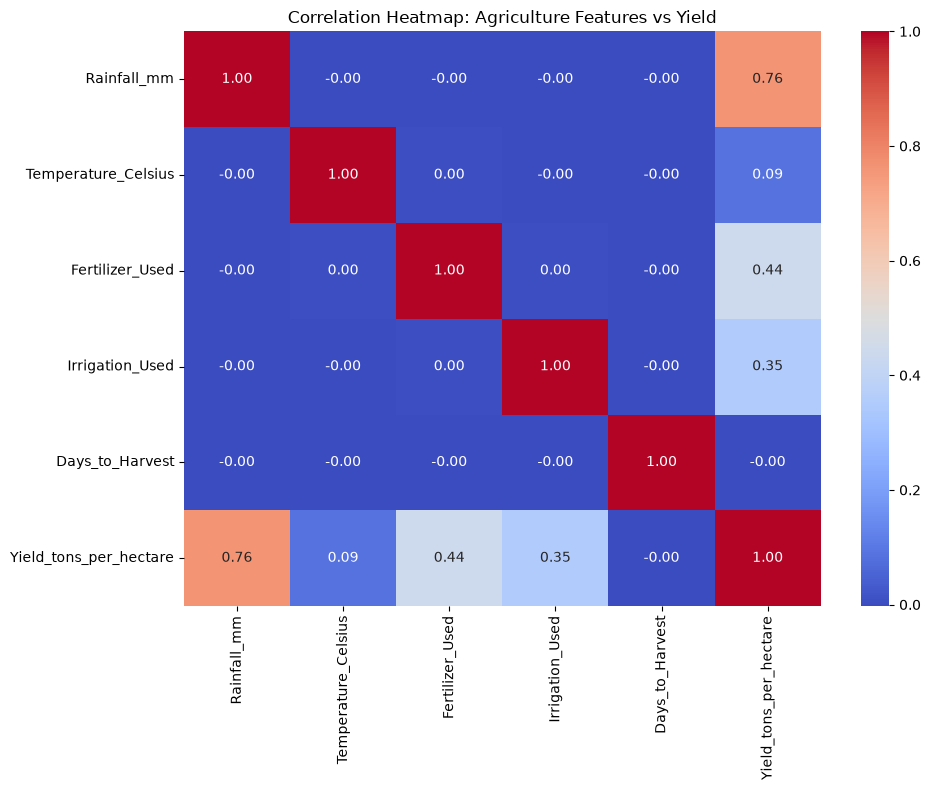

In [15]:
# REQUIREMENT: Data Visualization & Interpretation
# ---------------------------------------------------------
# We will plot a correlation heatmap for the numerical features against the Target
print("Generating Correlation Heatmap...")
plt.figure(figsize=(10, 8))
numeric_cols = ['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Days_to_Harvest', 'Yield_tons_per_hectare']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Agriculture Features vs Yield")
plt.tight_layout()
plt.show()

In [16]:
Y = df['Yield_tons_per_hectare'].values
X = df.drop(columns=['Yield_tons_per_hectare'])
feature_names = X.columns # Save feature names for later
X = X.values

In [17]:
# ---------------------------------------------------------
# REQUIREMENT: Standardize the Data
# ---------------------------------------------------------
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:

# ---------------------------------------------------------
# REQUIREMENT: Compare Stochastic Linear Regression vs 3 Others
# ---------------------------------------------------------
print("\n--- ALGORITHM COMPARISON ---")
models = {
    "Stochastic Linear Regression (SGD)": SGDRegressor(max_iter=1000, random_state=42),
    "Ordinary Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Lasso Regression": Lasso(alpha=0.01, random_state=42)
}

best_model = None
best_name = ""
best_rmse = float('inf')

for name, model in models.items():
    model.fit(X_train_scaled, Y_train)
    predictions = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(Y_test, predictions))
    print(f"{name} RMSE: {rmse:.4f} tons/hectare")
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_name = name

print(f"\n=> BEST MODEL: {best_name} with RMSE: {best_rmse:.4f}")


--- ALGORITHM COMPARISON ---
Stochastic Linear Regression (SGD) RMSE: 0.5012 tons/hectare
Ordinary Linear Regression RMSE: 0.5008 tons/hectare
Ridge Regression RMSE: 0.5008 tons/hectare
Lasso Regression RMSE: 0.5012 tons/hectare

=> BEST MODEL: Ordinary Linear Regression with RMSE: 0.5008



Generating Loss Curve for Stochastic Linear Regression...
finishedepch 0
finishedepch 1
finishedepch 2
finishedepch 3
finishedepch 4
finishedepch 5
finishedepch 6
finishedepch 7
finishedepch 8
finishedepch 9
finishedepch 10
finishedepch 11
finishedepch 12
finishedepch 13
finishedepch 14
finishedepch 15
finishedepch 16
finishedepch 17
finishedepch 18
finishedepch 19
finishedepch 20
finishedepch 21
finishedepch 22
finishedepch 23
finishedepch 24
finishedepch 25
finishedepch 26
finishedepch 27
finishedepch 28
finishedepch 29
finishedepch 30
finishedepch 31
finishedepch 32
finishedepch 33
finishedepch 34
finishedepch 35
finishedepch 36
finishedepch 37
finishedepch 38
finishedepch 39
finishedepch 40
finishedepch 41
finishedepch 42
finishedepch 43
finishedepch 44
finishedepch 45
finishedepch 46
finishedepch 47
finishedepch 48
finishedepch 49
finishedepch 50
finishedepch 51
finishedepch 52
finishedepch 53
finishedepch 54
finishedepch 55
finishedepch 56
finishedepch 57
finishedepch 58
finishe

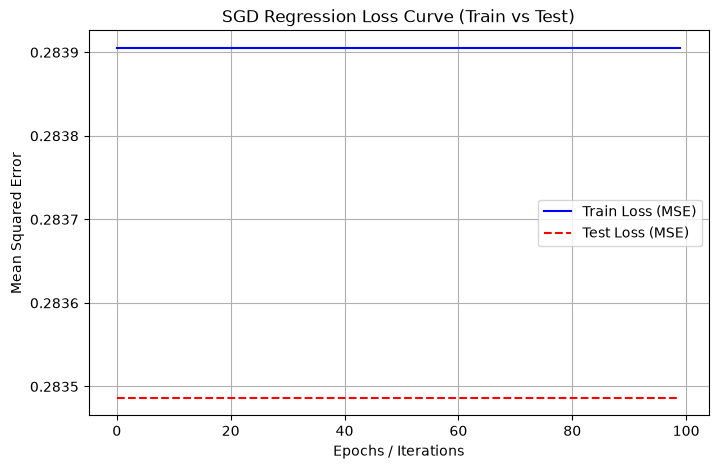

In [19]:

# ---------------------------------------------------------
# REQUIREMENT: Plot Loss Curve for Train and Test data
# ---------------------------------------------------------
print("\nGenerating Loss Curve for Stochastic Linear Regression...")
sgd_loss_model = SGDRegressor(max_iter=1, tol=None, warm_start=True, learning_rate='constant', eta0=0.01, random_state=42)

train_losses, test_losses = [], []
epochs = 100

# We use partial_fit to train it step-by-step so we can record the loss at each step
for epoch in range(epochs):
    sgd_loss_model.partial_fit(X_train_scaled, Y_train)
    
    # Calculate MSE for this epoch
    train_mse = mean_squared_error(Y_train, sgd_loss_model.predict(X_train_scaled))
    test_mse = mean_squared_error(Y_test, sgd_loss_model.predict(X_test_scaled))
    
    train_losses.append(train_mse)
    test_losses.append(test_mse)
    print(f"finishedepch {epoch}")

plt.figure(figsize=(8, 5))
plt.plot(range(epochs), train_losses, label='Train Loss (MSE)', color='blue')
plt.plot(range(epochs), test_losses, label='Test Loss (MSE)', color='red', linestyle='--')
plt.title("SGD Regression Loss Curve (Train vs Test)")
plt.xlabel("Epochs / Iterations")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()



Generating Scatter Plot with Regression Line...


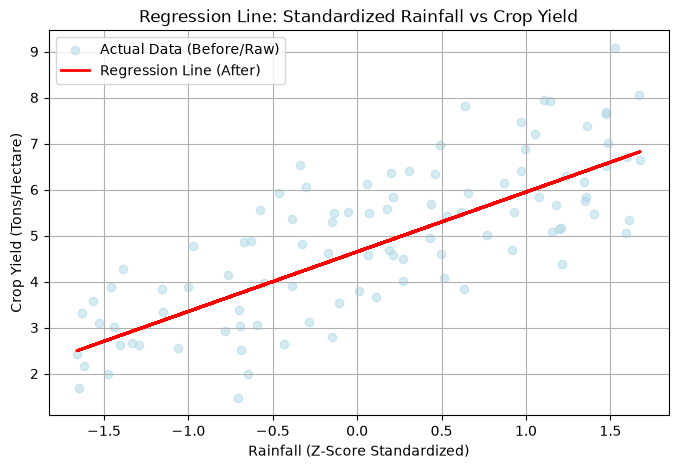

In [20]:

# ---------------------------------------------------------
# REQUIREMENT: Scatter plot with the Regression Line
# ---------------------------------------------------------
print("\nGenerating Scatter Plot with Regression Line...")
# To draw a 2D line, we must isolate a single feature. Let's use Rainfall (Index 0).
# We take a sample of 1,000 rows so matplotlib doesn't crash from 1,000,000 dots!
sample_size = 100
X_test_sample = X_test_scaled[:sample_size, 0].reshape(-1, 1) # Column 0 is Rainfall_mm
Y_test_sample = Y_test[:sample_size]

# Train a 1D model just for this visualization
single_feature_model = LinearRegression()
single_feature_model.fit(X_train_scaled[:, 0].reshape(-1, 1), Y_train)
Y_pred_line = single_feature_model.predict(X_test_sample)

plt.figure(figsize=(8, 5))
plt.scatter(X_test_sample, Y_test_sample, color='lightblue', label='Actual Data (Before/Raw)', alpha=0.5)
plt.plot(X_test_sample, Y_pred_line, color='red', linewidth=2, label='Regression Line (After)')
plt.title("Regression Line: Standardized Rainfall vs Crop Yield")
plt.xlabel("Rainfall (Z-Score Standardized)")
plt.ylabel("Crop Yield (Tons/Hectare)")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Save the winning model, scaler, and feature names using your existing joblib import
joblib.dump(best_model, 'best_crop_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

print(f"Successfully saved '{best_name}', scaler, and feature names to disk for Task 2!")

Successfully saved 'Ordinary Linear Regression', scaler, and feature names to disk for Task 2!


--- TASK 2: CROP YIELD PREDICTION SCRIPT ---
Successfully loaded model, scaler, and feature structures.

INPUT CONDITIONS: Wheat in North Region (Loam Soil)
Rainfall: 720.5mm | Temp: 24.8°C
--------------------------------------------------
PREDICTED YIELD: 6.7947 Tons per Hectare
